<a href="https://colab.research.google.com/github/vicky5859/computer-vison-/blob/main/EX%3A39.Vehicle%20Detection%20in%20a%20Video%20frame%20using%20OpenCV.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 4.4 MB/s eta 0:00:00


In [6]:
from google.colab import files

uploaded = files.upload()

video_name = list(uploaded.keys())[0]

print("Uploaded:", video_name)


Saving 9a504853-adae-454f-a6ab-45ba58cffec6.png to 9a504853-adae-454f-a6ab-45ba58cffec6.png
Uploaded: 9a504853-adae-454f-a6ab-45ba58cffec6.png


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.

0: 384x640 2 persons, 3 cars, 1 motorcycle, 2 buss, 1 truck, 314.0ms
Speed: 12.4ms preprocess, 314.0ms inference, 34.3ms postprocess per image at shape (1, 3, 384, 640)


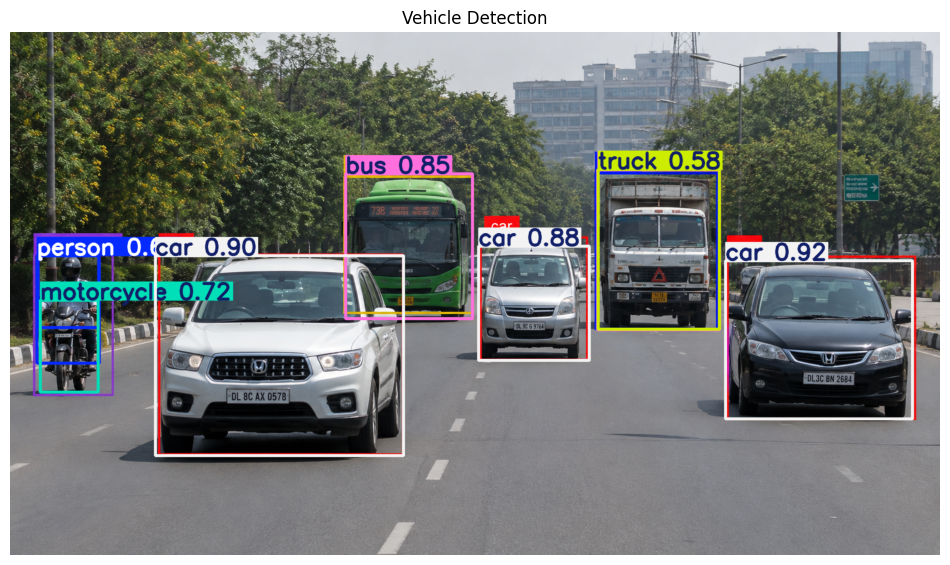

Vehicles detected: 7


In [7]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

# Load YOLO model
model = YOLO("yolo11n.pt")

# Open video
cap = cv2.VideoCapture(video_name)

# Read first frame
ret, frame = cap.read()

cap.release()

if ret:
    # Run YOLO detection
    results = model(frame)

    # Vehicle classes in COCO
    vehicle_classes = [
        "car",
        "motorcycle",
        "bus",
        "truck"
    ]

    vehicle_count = 0

    # Draw detections
    for result in results:
        boxes = result.boxes

        for box in boxes:
            class_id = int(box.cls[0])
            class_name = model.names[class_id]

            if class_name in vehicle_classes:
                vehicle_count += 1

    # Plot result
    annotated_frame = results[0].plot()

    annotated_rgb = cv2.cvtColor(
        annotated_frame,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(12, 7))
    plt.imshow(annotated_rgb)
    plt.axis("off")
    plt.title("Vehicle Detection")
    plt.show()

    print("Vehicles detected:", vehicle_count)

else:
    print("Unable to read video.")